# Smart Restaurant Food Management 


In [78]:
import pandas as pd 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib
from sklearn.metrics import accuracy_score



In [79]:
df = pd.read_csv(r"C:\Users\Administrator\Downloads\Hackathon\Food_Images_Dataset\Resturant data\Book1 new.csv", sep=';')
df.head()

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,Prepared Meals,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25
1,Prepared Meals,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,40
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27
3,Prepared Meals,491,Birthday,497,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,32
4,Prepared Meals,300,Corporate,400,Refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25


## Dataset overview

In [80]:
rows,columns=df.shape
print(f"Number of rows is:{rows}")
print(f"Number of columns is:{columns}")

Number of rows is:1782
Number of columns is:11


In [81]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1782 entries, 0 to 1781
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Type of Food           1782 non-null   object
 1   Number of Guests       1782 non-null   int64 
 2   Event Type             1782 non-null   object
 3   Quantity of Food       1782 non-null   int64 
 4   Storage Conditions     1782 non-null   object
 5   Purchase History       1782 non-null   object
 6   Seasonality            1782 non-null   object
 7   Preparation Method     1782 non-null   object
 8   Geographical Location  1782 non-null   object
 9   Pricing                1782 non-null   object
 10  Wastage Food Amount    1782 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 153.3+ KB


In [82]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 131


### 🛠️ Data Cleaning
1. **Duplicate Rows:** Found 164 duplicate rows that can cause model overfitting.
2. **Data Integrity:** Need to reset the dataset index after removing duplicates.

In [83]:

df = df.drop_duplicates()
df = df.reset_index(drop=True)
print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (1651, 11)


## 🛠️ Feature Engineering: 
We will create a custom `Target_Class` based on food safety indicators (Storage Conditions, Food Type, and Wastage Amount) following **WHO Food Safety Guidelines**. 

**Target Classes:**
* `0`: Safe for Consumption (Restaurant Serving)
* `1`: Safe for Donation (Food Banks)
* `2`: Animal Feed Transformation
* `3`: Biogas & Organic Compost Production

In [84]:
print(df['Type of Food'].unique())
print(df['Storage Conditions'].unique())

['Prepared Meals' 'Vegetables' 'Fruits' 'Baked Goods' 'Meat'
 'Dairy Products']
['Refrigerated' 'Room Temperature']


In [85]:
def calculate_target(row):
    score = 100
    
    if row['Storage Conditions'] == 'Room Temperature':
        score -= 40
    elif row['Storage Conditions'] == 'Refrigerated':
        score -= 10
        
    if row['Type of Food'] == 'Meat':
        score -= 20
    elif row['Type of Food'] in ['Dairy Products', 'Baked Goods', 'Prepared Meals']:
        score -= 15
    elif row['Type of Food'] in ['Vegetables', 'Fruits']:
        score -= 10
        
    if row['Wastage Food Amount'] > 40:
        score -= 20
    elif row['Wastage Food Amount'] > 25:
        score -= 10
        
    if score >= 65:
        return 0
    elif score >= 45:
        return 1
    elif score >= 35:
        return 2
    else:
        return 3

df['Target_Class'] = df.apply(calculate_target, axis=1)
print(df['Target_Class'].value_counts())

Target_Class
1    645
2    461
0    432
3    113
Name: count, dtype: int64


In [86]:
df.head(10)

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount,Target_Class
0,Prepared Meals,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25,0
1,Prepared Meals,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,40,2
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27,0
3,Prepared Meals,491,Birthday,497,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,32,0
4,Prepared Meals,300,Corporate,400,Refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25,0
5,Prepared Meals,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27,0
6,Prepared Meals,240,Wedding,450,Refrigerated,Regular,Winter,Sit-down Dinner,Urban,Low,20,0
7,Prepared Meals,300,Wedding,400,Refrigerated,Regular,Summer,Finger Food,Rural,Moderate,25,0
8,Fruits,320,Corporate,400,Refrigerated,Regular,All Seasons,Buffet,Urban,High,45,1
9,Prepared Meals,400,Corporate,500,Refrigerated,Occasional,Winter,Finger Food,Urban,High,40,0


### Adding Wastage Ratio
To improve the model's predictive power, we will engineer a new feature called `Wastage_Ratio`. 



In [87]:
df['Wastage_Ratio'] = (((df['Wastage Food Amount'] / df['Quantity of Food']) * 100).round(2))
display(df[['Quantity of Food', 'Wastage Food Amount', 'Wastage_Ratio']].head())

,Quantity of Food,Wastage Food Amount,Wastage_Ratio
0,450,25,5.56
1,500,40,8.00
2,371,27,7.28
3,497,32,6.44
4,400,25,6.25


## 🔠 Categorical Encoding
We will use `LabelEncoder` transform all text-based categorical features into numerical values. 
* Note: The engineered feature `Wastage_Ratio` is kept as a pure numerical float to allow tree models to utilize its continuous distribution.

In [88]:

categorical_cols = ['Type of Food', 'Event Type', 'Storage Conditions', 
                    'Purchase History', 'Seasonality', 'Preparation Method', 
                    'Geographical Location', 'Pricing']

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
display(df.head())

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount,Target_Class,Wastage_Ratio
0,4,310,1,450,0,1,0,0,2,1,25,0,5.56
1,4,400,0,500,1,1,2,0,1,0,40,2,8.00
2,5,302,0,371,0,1,1,0,1,1,27,0,7.28
3,4,491,0,497,0,1,0,1,0,0,32,0,6.44
4,4,300,1,400,0,1,2,1,2,2,25,0,6.25


## ✂️ Data Splitting
We will separate our data into features (`X`) and the target variable (`y`). Then, we split them into **80% Training** and **20% Testing** sets, using stratification to ensure balanced classes.

In [89]:

X = df[['Storage Conditions', 'Number of Guests', 'Type of Food', 'Pricing']]
y = df['Target_Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train Shape: {X_train.shape} | y_train Shape: {y_train.shape}")
print(f"X_test Shape: {X_test.shape}   | y_test Shape: {y_test.shape}")

X_train Shape: (1320, 4) | y_train Shape: (1320,)
X_test Shape: (331, 4)   | y_test Shape: (331,)


## 🤖 Model Training
In this section, we will initialize and train two different Tree-based models:
1. **Decision Tree Classifier**
2. **Random Forest Classifier**

We will train both models using the training dataset (`X_train`, `y_train`) to learn the patterns for our food classification system.

In [90]:
decision_tree_model = DecisionTreeClassifier(random_state=42)
random_forest_model = RandomForestClassifier(random_state=42)

decision_tree_model.fit(X_train, y_train)
print("Decision Tree Model trained successfully!")

random_forest_model.fit(X_train, y_train)
print("Random Forest Model trained successfully!")

Decision Tree Model trained successfully!
Random Forest Model trained successfully!


## 📊 Model Evaluation & Comparison
We will now test both models. We will evaluate their performance using the **Accuracy Score** and the comprehensive **Classification Report**.

In [91]:
dt_predictions = decision_tree_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)

rf_predictions = random_forest_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Decision Tree Accuracy : {dt_accuracy * 100:.2f}%")
print(f"Random Forest Accuracy : {rf_accuracy * 100:.2f}%")

print("Classification Report for Decision Tree:")
print(classification_report(y_test, dt_predictions))

print("Classification Report for Random Forest:")
print(classification_report(y_test, rf_predictions))

Decision Tree Accuracy : 89.73%
Random Forest Accuracy : 90.33%
Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        87
           1       0.93      0.95      0.94       129
           2       0.82      0.87      0.85        92
           3       0.70      0.30      0.42        23

    accuracy                           0.90       331
   macro avg       0.85      0.78      0.80       331
weighted avg       0.89      0.90      0.89       331

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        87
           1       0.95      0.96      0.95       129
           2       0.83      0.90      0.86        92
           3       0.67      0.26      0.38        23

    accuracy                           0.90       331
   macro avg       0.85      0.78      0.79       331
weighted avg       0.89      0.90      

In [92]:

train_predictions = random_forest_model.predict(X_train)

train_acc = accuracy_score(y_train, train_predictions) * 100
test_acc = accuracy_score(y_test, rf_predictions) * 100 

print(f"training accuracy: {train_acc:.2f}%")
print(f"testing accuracy: {test_acc:.2f}%")


training accuracy: 93.64%
testing accuracy: 90.33%


## 📊 Feature Importance Visualization
Let's visualize which factors (features) contributed the most to the Random Forest model's decisions.

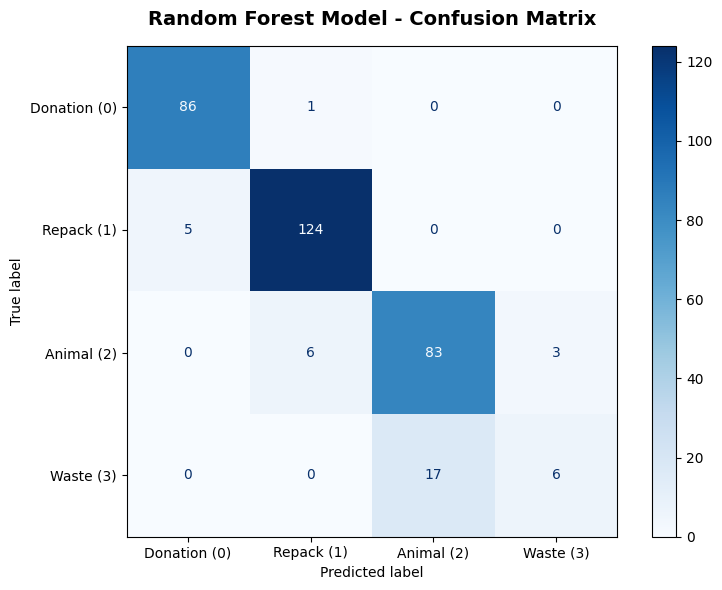

In [93]:

cm = confusion_matrix(y_test, rf_predictions)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Donation (0)', 'Repack (1)', 'Animal (2)', 'Waste (3)'])

disp.plot(cmap='Blues', values_format='d', ax=plt.gca())

plt.title('Random Forest Model - Confusion Matrix', fontsize=14, weight='bold', pad=15)
plt.grid(False)
plt.tight_layout()
plt.show()

In [94]:

joblib.dump(random_forest_model, 'restaurant_model_v2.pkl')
print("Model saved successfully")

Model saved successfully
